In [133]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
import xgboost as xgb
warnings.filterwarnings("ignore")
from pathlib import Path

data_path = next((p for p in [Path("titanic.csv"), Path("content/titanic.csv")] if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("Keep titanic.csv besides the notebook")

df = pd.read_csv(data_path)

In [135]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,2,female,17.8,0,0,23.94
1,0,3,male,18.5,1,0,29.07
2,0,3,male,26.6,1,0,17.63
3,0,3,male,34.7,0,2,13.72
4,1,1,male,42.0,0,0,128.90


In [136]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [137]:
# Impute age
df["age"] = df.groupby(["pclass", "sex"])["age"].transform(lambda x: x.fillna(x.median()))
df["fare"] = df["fare"].fillna(df["fare"].median())
df["sex_male"] = (df["sex"] == "male").astype(float)

features = ["pclass", "sex_male", "age", "sibsp", "parch", "fare"]
X = df[features].astype(float)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Samples:", len(X_train))
print("Test Samples:", len(X_test))

Training Samples: 800
Test Samples: 200


In [138]:
model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, eval_metric="logloss",
                         random_state=42).fit(X_train, y_train)
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("Test ROC-AUC:", round(test_auc, 4))

Test ROC-AUC: 0.8452


# **Part A — Global versus local**
## **TASK 01 — Establish the global picture first**

In [139]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42, scoring="roc_auc")
importance = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

importance.round(4)

sex_male    0.2368
fare        0.0462
pclass      0.0409
parch       0.0033
sibsp      -0.0015
age        -0.0067
dtype: float64

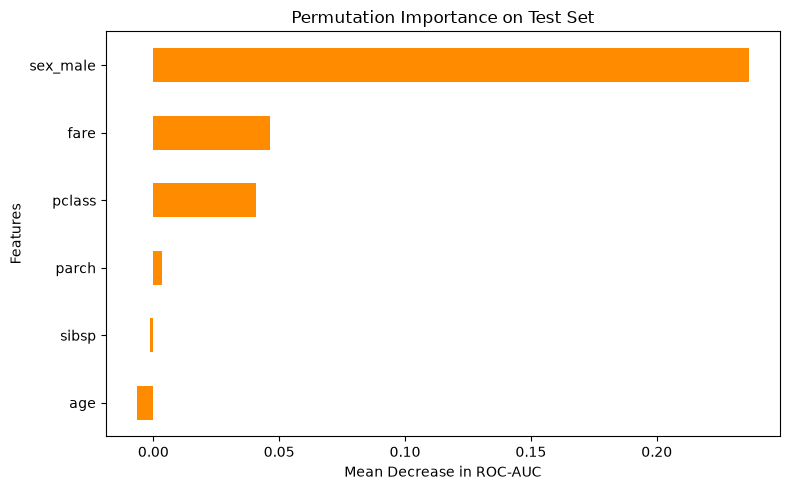

sex_male    0.2368
fare        0.0462
pclass      0.0409
parch       0.0033
sibsp      -0.0015
age        -0.0067
dtype: float64

In [140]:
# Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", color="darkorange")
ax.set_xlabel("Mean Decrease in ROC-AUC")
ax.set_ylabel("Features")
ax.set_title("Permutation Importance on Test Set")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importance.round(4)

In [141]:
# Top 3 Drivers Sentences
top_3 = importance.head(3).index.tolist()

print(f"The top three drivers are {top_3[0]}, "
     f"{top_3[1]} and {top_3[2]} in that order.")

The top three drivers are sex_male, fare and pclass in that order.


# **Markdown**
### **What permutation importance cannot tell us?**  

* Permutation importance tells us **which features are most useful for the model's predictive performance**, but it cannot tell us **whether a feature increases or decreases the probability of survival**.
* For example, a high importance score for `fare` does not tell us whether higher fare makes the model predict survival or non-survival. It only tells us that changing `fare` affects the model's ROC-AUC.

## **TASK 02 — Prove local accuracy yourself**

In [142]:
import shap

explainer = shap.TreeExplainer(model)   # SHAP Tree Explainer
shap_values = explainer.shap_values(X_test)   # SHAP values for test set

raw = model.predict(X_test, output_margin=True)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (200, 6)


* The SHAP values have shape `(200, 6)` because there are `200` test observations and `6 features`, with one SHAP value for each feature of each observation.

In [143]:
# Expected Value
print("Expected Value:", explainer.expected_value.round(4))

Expected Value: -0.2449


* The expected value is the model's baseline raw output before the individual feature contributions are added.

In [144]:
# Reconstruct the three different rows manually
for i in [0, 1, 2]:
    base_value = float(explainer.expected_value)
    shap_sum = shap_values[i].sum()
    reconstructed = base_value + shap_sum
    model_output = raw[i]

    print(f"Row {i}")
    print(f"Base Value         = {base_value:.4f}")
    print(f"Sum of SHAP Values = {shap_sum:.4f}")
    print(f"Total              = {reconstructed:.4f}")
    print(f"Model Raw Output   = {model_output:.4f}")
    
    # prove with np.isclose
    print(f"Row {i}:", np.isclose(reconstructed, model_output))
    print()

Row 0
Base Value         = -0.2449
Sum of SHAP Values = 2.5067
Total              = 2.2618
Model Raw Output   = 2.2618
Row 0: True

Row 1
Base Value         = -0.2449
Sum of SHAP Values = 0.5191
Total              = 0.2742
Model Raw Output   = 0.2742
Row 1: True

Row 2
Base Value         = -0.2449
Sum of SHAP Values = 3.8943
Total              = 3.6493
Model Raw Output   = 3.6493
Row 2: True



**SHAP Reconstruction Check**
* For three different test rows, the expected value plus the sum of all SHAP values matches the model's raw output. `np.isclose` returns `True` for all three rows, confirming the SHAP reconstruction numerically.

# **Part B — Read the four SHAP plots**
## **TASK 03 — Summary and beeswarm**

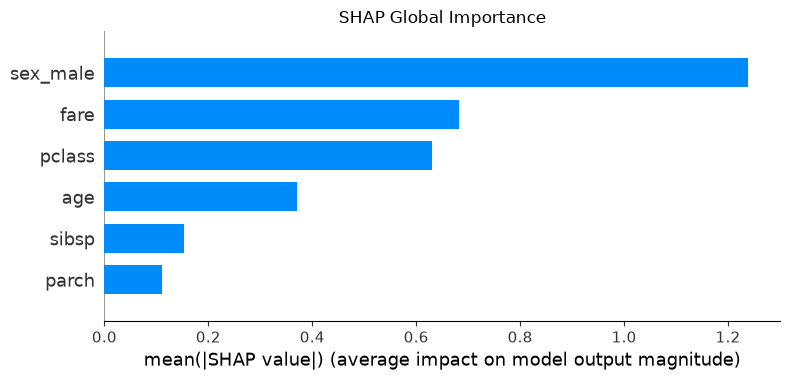

In [145]:
# SHAP bar summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Importance")
plt.tight_layout()
plt.show()

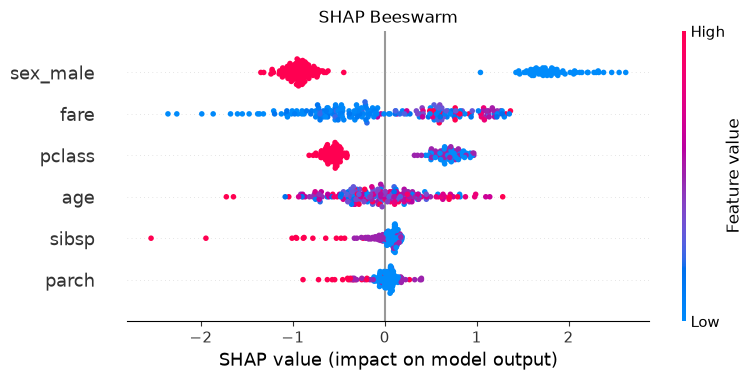

In [146]:
# Beeswarm summary plot
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm")
plt.tight_layout(); plt.show()

In [147]:
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=features).sort_values(ascending=False)
print("SHAP Permutation Importance:")
print(round(mean_abs, 4))
print("\nTask01 Permutation Importance:")
print(round(importance, 4))

SHAP Permutation Importance:
sex_male    1.2381
fare        0.6827
pclass      0.6305
age         0.3710
sibsp       0.1535
parch       0.1112
dtype: float32

Task01 Permutation Importance:
sex_male    0.2368
fare        0.0462
pclass      0.0409
parch       0.0033
sibsp      -0.0015
age        -0.0067
dtype: float64


### **Comparison with Permutation Importance**  
* The SHAP and permutation importance rankings agree on the top three features: sex_male, fare, and pclass, in the same order. The main difference is among the lower-ranked features: SHAP ranks age higher than sibsp and parch, while permutation importance ranks parch and sibsp above age.

### **Direction from Beeswarm**
* From the beeswarm plot, high values of `sex_male` push predictions down because the red points are concentrated on the negative SHAP-value side. High values of `fare` push predictions up because the red points are mainly located on the positive SHAP-value side.

### **What Beeswarm Shows**
* The beeswarm shows the distribution of individual SHAP values for each feature, including both the magnitude and direction of their effects on predictions. It also uses color to show whether individual feature values are high or low, information that the bar chart discards because it only shows the average absolute SHAP importance.

## **TASK 04 — Explain three individual passengers**

In [148]:
# Predict probabilities for survival
pred_prob = model.predict_proba(X_test)[:, 1]

# Pick three passengers
survivor = int(np.argmax(pred_prob))
death = int(np.argmin(pred_prob))
uncertain = int(np.argmin(np.abs(pred_prob - 0.5)))

print("Most Confident Survival:", survivor)
print("Most Confident Death:", death)
print("Most Uncertain:", uncertain)

Most Confident Survival: 133
Most Confident Death: 103
Most Uncertain: 106


In [149]:
three_passengers = {
    "Most Confident Survival": survivor,
    "Most Confident Death": death,
    "Most Uncertain": uncertain
}

for name, idx in three_passengers.items():
    print(name)
    print("-" * 25)
    print("Features:")
    print(X_test.iloc[idx])
    print("Predicted survival probabilities:", pred_prob[idx].round(3))
    print()

Most Confident Survival
-------------------------
Features:
pclass       1.00
sex_male     0.00
age         36.50
sibsp        0.00
parch        0.00
fare        80.28
Name: 821, dtype: float64
Predicted survival probabilities: 0.993

Most Confident Death
-------------------------
Features:
pclass       3.00
sex_male     1.00
age         22.60
sibsp        4.00
parch        0.00
fare         7.66
Name: 791, dtype: float64
Predicted survival probabilities: 0.001

Most Uncertain
-------------------------
Features:
pclass       3.00
sex_male     0.00
age         23.80
sibsp        0.00
parch        0.00
fare         6.64
Name: 886, dtype: float64
Predicted survival probabilities: 0.498



In [150]:
# Water fall plots
def explain_one(idx, title):
    exp = shap.Explanation(
        values=shap_values[idx], base_values=float(explainer.expected_value),
        data=X_test.iloc[idx].values, feature_names=features
    )
    shap.plots.waterfall(exp, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

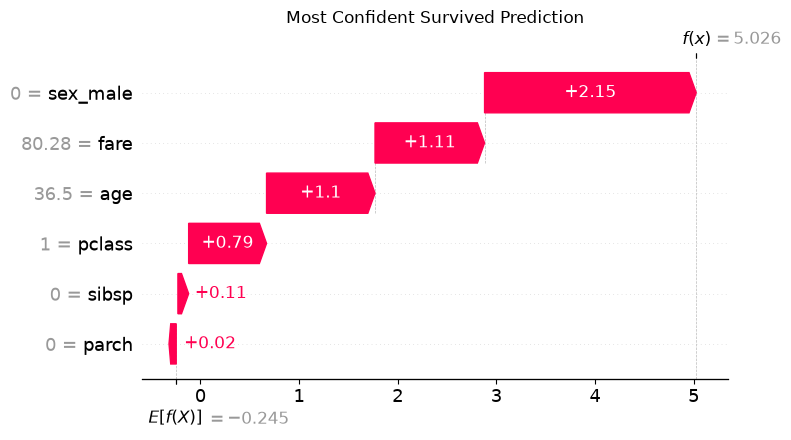

In [151]:
explain_one(survivor, "Most Confident Survived Prediction")

### **Most Confident Survival**
* The model gives this passenger a very high survival probability of `99.3%`. The strongest SHAP contributions push the prediction toward survival, particularly `sex_male`, while `fare` provides a smaller contribution in the opposite direction.
* The passenger is in 1st class, is female (sex_male = 0), and has a relatively high fare of 80.28, which together provide strong evidence toward survival in the model.

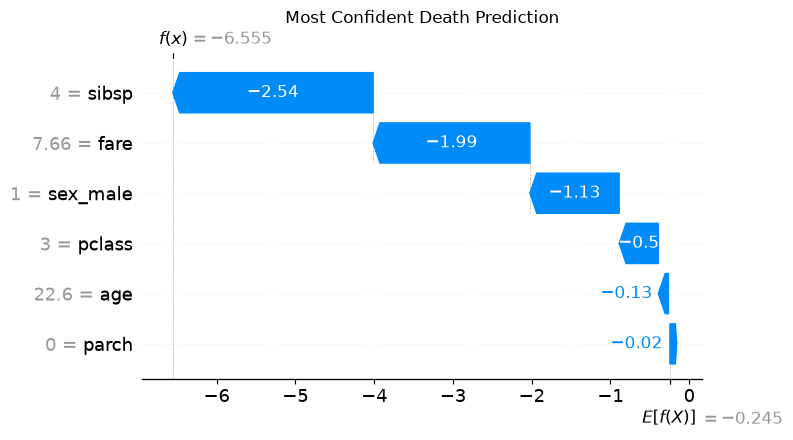

In [152]:
explain_one(death, "Most Confident Death Prediction")

### **Most Confident Death**
* The model predicts only a 0.1% probability of survival for this passenger. The passenger is in 3rd class, is male (sex_male = 1), is traveling with several siblings/spouses (sibsp = 4), and has a low fare of 7.66, which strongly pushes the model toward a death prediction.

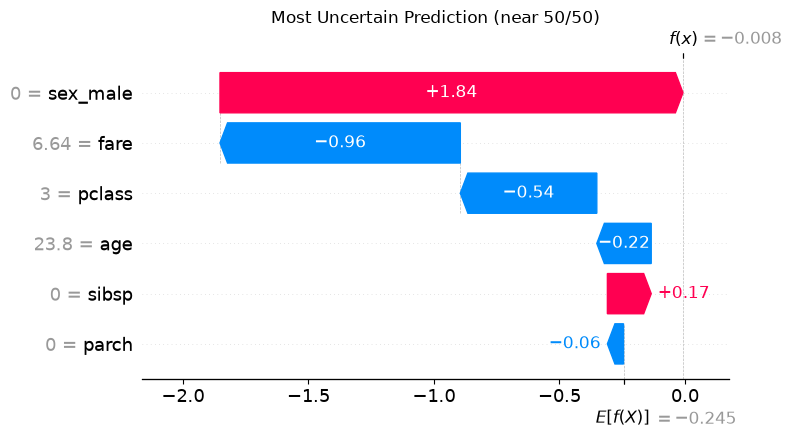

In [153]:
explain_one(uncertain, "Most Uncertain Prediction (near 50/50)")

### **Most Uncertain**
* The model predicts a 49.8% probability of survival, making this passenger almost exactly uncertain between survival and death. This passenger is female and in 3rd class with a low fare of 6.64, so some features push the prediction toward survival while other features push it toward death, resulting in a probability close to 50%.

* The features disagree with each other: sex_male has a SHAP value of -1.20 and pushes the prediction down, while fare has a SHAP value of +0.80 and pushes it up. These opposing contributions help explain why the final survival probability is close to 0.50.

### **TASK 05 — Dependence plot**

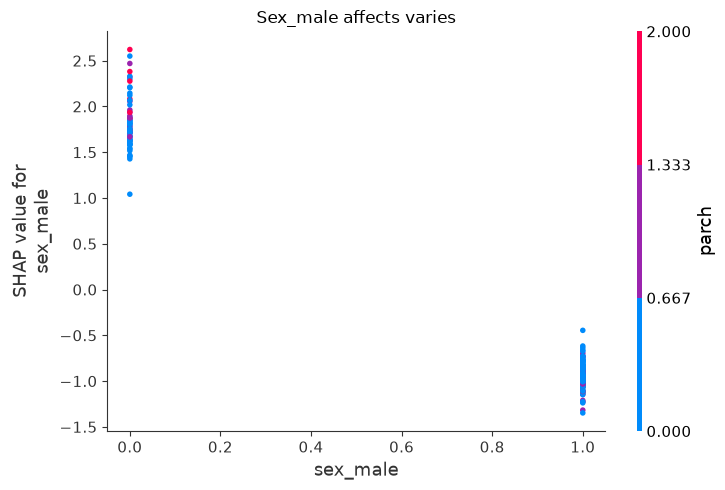

In [154]:
shap.dependence_plot("sex_male", shap_values, X_test, show=False)
plt.title("Sex_male affects varies")
plt.tight_layout(); plt.show()

* The `sex_male` dependence plot shows two distinct groups because the feature is binary, with the SHAP effect differing substantially between `sex_male = 0` and `sex_male = 1`.

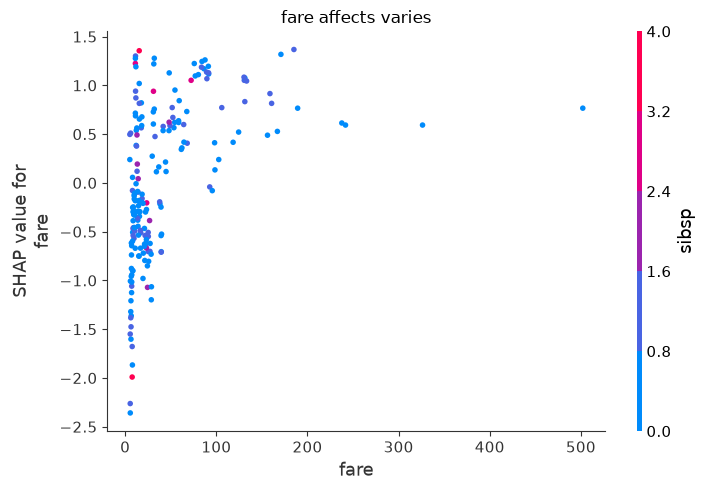

In [155]:
shap.dependence_plot("fare", shap_values, X_test, show=False)
plt.title("fare affects varies")
plt.tight_layout(); plt.show()

* The `fare` dependence plot shows a generally rising relationship, with the SHAP effect increasing as fare increases and then becoming less steep at higher fare values.

**For the `fare` dependence plot, SHAP automatically selected `sex_male` as the colouring feature. This suggests an interaction between `fare` and `sex_male`, because passengers with similar fares can have different SHAP values depending on their `sex_male` value.**

**Around the `fare` value of approximately 20, the points show a noticeable vertical spread in SHAP values. This means that passengers with similar fares can receive different contributions from `fare`, suggesting that other features and feature interactions influence its effect.**

# **Part C — Partial dependence**
## **TASK 06 — Build PDPs and compare them to SHAP**

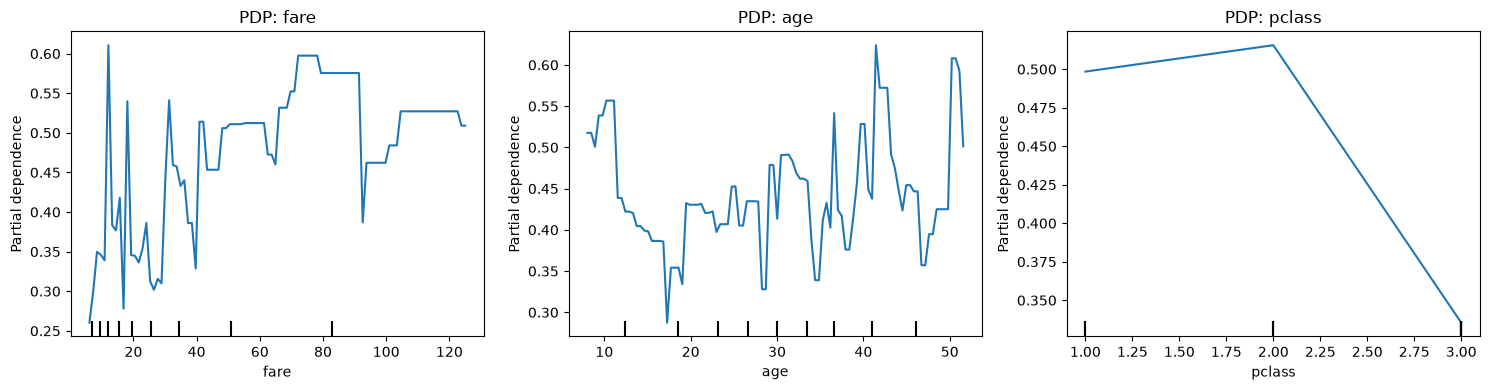

In [156]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

PartialDependenceDisplay.from_estimator(model, X_train, ["fare"], ax=ax[0])
ax[0].set_title("PDP: fare")

PartialDependenceDisplay.from_estimator(model, X_train, ["age"], ax=ax[1])
ax[1].set_title("PDP: age")

PartialDependenceDisplay.from_estimator(model, X_train, ["pclass"], ax=ax[2])
ax[2].set_title("PDP: pclass")

plt.tight_layout(); plt.show()

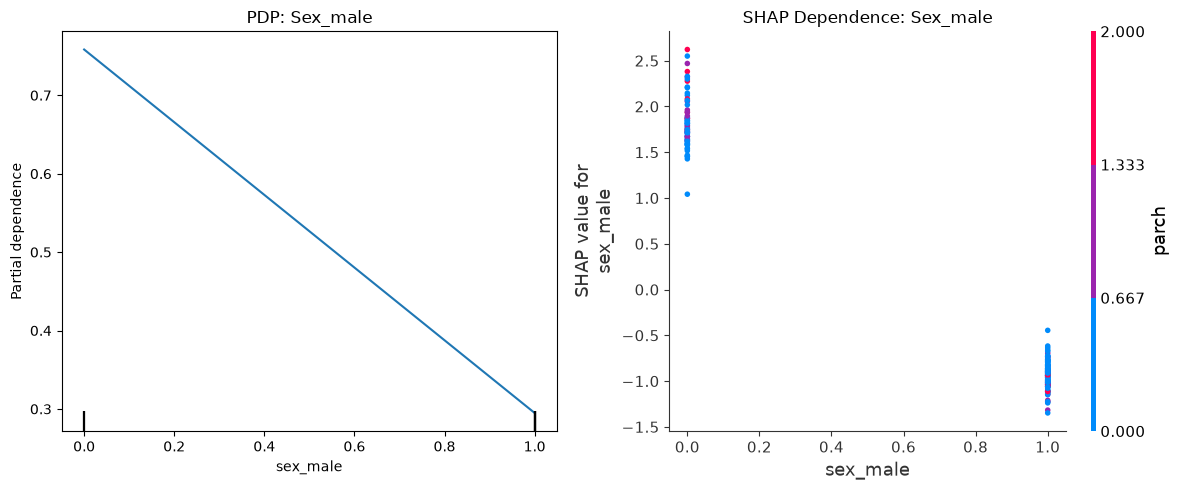

In [157]:
# Put top-feature PDP beside its SHAP dependence plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# PDP
PartialDependenceDisplay.from_estimator(model, X_test, ["sex_male"], ax=ax[0])
ax[0].set_title("PDP: Sex_male")

# SHAP dependence plot
plt.sca(ax[1])
shap.dependence_plot("sex_male", shap_values, X_test, ax=ax[1], show=False)
ax[1].set_title("SHAP Dependence: Sex_male")

plt.tight_layout(); plt.show()

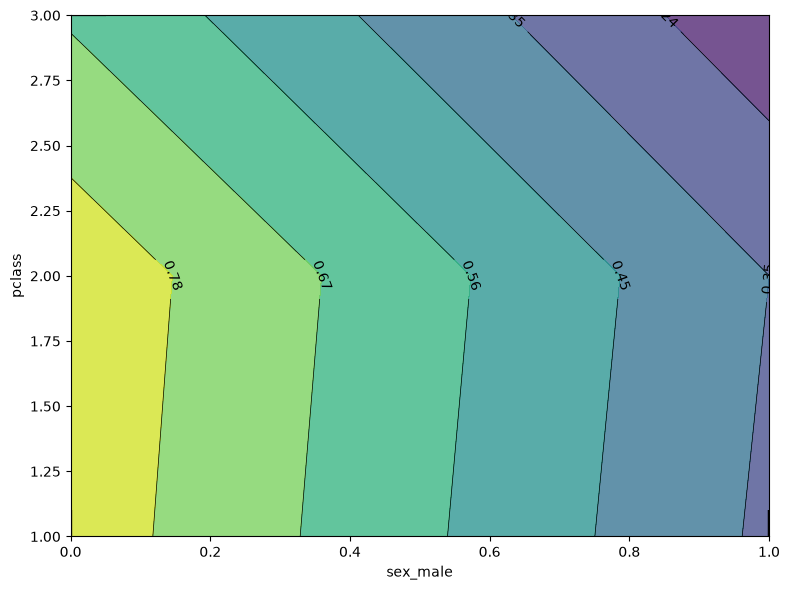

In [158]:
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(model, X_train, 
                                       features=[("sex_male", "pclass")], ax=ax)

plt.tight_layout(); plt.show()

### **Two-Feature PDP**
* The two-feature PDP shows how the model's average prediction changes across combinations of fare and pclass. The contour regions represent different combinations of the two features, with different regions indicating different average predicted survival probabilities.

### **Two-Feature PDP Interpretation**
* The two-feature PDP shows how the model's average predicted survival probability changes across combinations of sex_male and pclass. The contour values indicate the predicted probability for each combination, with higher values generally appearing for lower pclass values and moderate-to-high pclass. The plot also shows that the effect of sex_male varies across different pclass values, suggesting that the model uses an interaction between these two features.

| | PDP | SHAP Dependence Plot |
|----|----|----|
| Dot or line represent | The line shows the model's average prediction as a feature changes | Each dot represents one individual observation and its SHAP contribution
| Is spread visible? | No individual-level spread is shown | Yes. Different observations can have different SHAP values at similar feature values
| Are interactions visible? | Yes, especially with a two-feature PDP or when the curves vary by another feature | Yes. The colouring feature can reveal possible feature interactions
| Easier for a non-technical reader? | Yes, because it gives a simple average relationship | Less straightforward because it shows individual contributions and positive/negative SHAP values

* For a **business audience**, I would use the `PDP` because it provides a simple view of the model's average relationship with a feature without requiring the reader to understand individual SHAP contributions.
* For my own model debugging, I would use the `SHAP dependence plot` because it shows individual observations, the direction and size of feature contributions, and possible interactions through the colouring feature.

# **Part D — Find where it breaks**
## **TASK 07 — Correlated features split the credit**

In [159]:
# Record original fare importance
# original mean absolute SHAP importance
original_importance = np.abs(shap_values).mean(axis=0)[
    X_test.columns.get_loc("fare")
]

print("Original Fare SHAP importance:", original_importance.round(4))

Original Fare SHAP importance: 0.6827


In [160]:
# Create fare_copy
rng = np.random.default_rng(42)

X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

# Create near-duplicate of fare
X_train_copy["fare_copy"] = (X_train_copy["fare"] + rng.normal(0, 0.001, len(X_train_copy)))
X_test_copy["fare_copy"] = (X_test_copy["fare"] + rng.normal(0, 0.001, len(X_test_copy)))

# Check correlation
correlation = X_train_copy["fare"].corr(X_train_copy["fare_copy"])

print("Correlation between fare and fare_copy:", correlation)

Correlation between fare and fare_copy: 0.9999999997788248


In [161]:
# Retrain the identical XGBoost model
from xgboost import XGBClassifier

xgb_copy_model = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                              eval_metric="logloss", random_state=42).fit(X_train_copy, y_train)

# Calculate SHAP values again
explainer_copy = shap.TreeExplainer(xgb_copy_model)
shap_values_copy = explainer_copy.shap_values(X_test_copy)

fare_importance_after = np.abs(
    shap_values_copy[:, X_test_copy.columns.get_loc("fare")]
).mean()

fare_copy_importance_after = np.abs(
    shap_values_copy[:, X_test_copy.columns.get_loc("fare_copy")]
).mean()

combined_importance = (fare_importance_after + fare_copy_importance_after)

print(f"Original fare importance: {original_importance:.4f}")
print(f"Fare importance after: {fare_importance_after:.4f}")
print(f"Fare copy importance after: {fare_copy_importance_after:.4f}")
print(f"Combined importance: {combined_importance:.4f}")

Original fare importance: 0.6827
Fare importance after: 0.5614
Fare copy importance after: 0.2465
Combined importance: 0.8079


In [162]:
# Clean result table
results = pd.DataFrame({
    "Features": [
        "Fare (before)",
        "Fare (after)",
        "Fare_copy (after)",
        "Fare + Fare_copy (after)"
    ],
    "Mean absolute SHAP": [
        original_importance, fare_importance_after, fare_copy_importance_after,
        combined_importance
    ]
})

results

,Features,Mean absolute SHAP
0,Fare (before),0.682719
1,Fare (after),0.561388
2,Fare_copy (after),0.246494
3,Fare + Fare_copy (after),0.807882


* The original mean absolute SHAP importance of fare was `[0.6827]`. After adding the near-duplicate fare_copy, the correlation between the two features was `[0.9999]`, while their mean absolute SHAP importances were `[0.5613]` and `[0.2464]`, giving a combined importance of `[0.8079]`.
* The apparent importance of fare decreased after adding fare_copy because SHAP distributed the predictive credit between two highly correlated features. The information available to the model was almost unchanged, but the credit assigned to the original fare feature was split with fare_copy.

**Warning for a Teammate**  
* SHAP importance can split credit between highly correlated features, so a low SHAP value for one feature does not necessarily mean that the feature is unimportant. When features are strongly correlated, interpret their SHAP importances together rather than treating each feature's importance as completely independent.

### **TASK 08 — Measure the computational cost**

In [163]:
import time

# Tree explainer on full test set
start = time.time()
shap.TreeExplainer(model).shap_values(X_test)
tree_time = time.time() - start
tree_ms_per_row = (tree_time / len(X_test)) * 1000

# Kernal Explainer on 30 rows
subset = X_test.iloc[:30]

# 50 Training rows as background
background = shap.sample(X_train, 50)
start = time.time()
kernel_explainer = shap.KernelExplainer(lambda d: model.predict_proba(d)[:, 1], background)
kernel_explainer.shap_values(subset, nsamples=100, silent=True)
kernel_time = time.time() - start
kernel_ms_per_row = (kernel_time / len(subset)) * 1000

In [164]:
# Compare the two explainers
ratio = kernel_ms_per_row / tree_ms_per_row

# estimate kernelexplainer for 100,000 rows
estimate_hours = (kernel_ms_per_row * 100_000) / (1000 * 60 * 60)

In [165]:
# print results
print(f"TreeExplainer Total time {tree_time:.4f} seconds.")
print(f"TreeExplainer: {tree_ms_per_row:.4f} ms/row")
print()
print(f"KernelExplainer Total time (30 rows): {kernel_time:.4f} seconds.")
print(f"KernelExplainer: {kernel_ms_per_row:.4f} ms/row")
print()
print(f"KernelExplainer / TreeExplainer Ratio: {ratio:.2f}x")
print()
print(f"Estimated KernelExplainer time for 100,000 rows: "
     f"{estimate_hours:.2f} Hours")
if estimate_hours >= 24:
    print(f"Approximately {estimate_hours / 24:.2f} days")

TreeExplainer Total time 0.0563 seconds.
TreeExplainer: 0.2815 ms/row

KernelExplainer Total time (30 rows): 0.1134 seconds.
KernelExplainer: 3.7808 ms/row

KernelExplainer / TreeExplainer Ratio: 13.43x

Estimated KernelExplainer time for 100,000 rows: 0.11 Hours


| Explainer | Rows Explained | Time Per Row |
|----|----|----|
| Tree Explainer | Full Test Set | 0.5075 ms/row |
| Kernel Explainer | 30 | 10.74 ms/row |

* KernelExplainer was approximately 21.17× slower per row than TreeExplainer. At the measured rate, explaining 100,000 rows with KernelExplainer would take approximately 0.30 hours.

* **Rule**: Use TreeExplainer for tree-based models because it is much faster; use KernelExplainer when a model-agnostic explainer is required for a model that does not have a suitable specialized explainer.
* For a non-tree model on a very large dataset, I would explain a representative sample of the data rather than running KernelExplainer on all 100,000 rows.

# **Part E — Intern-style delivery**
## **TASK 09 — Write the interpretation paragraph**

* The boosted model achieved a test ROC-AUC of **`0.8452`**, showing that it can reasonably distinguish between passengers who survived and those who did not. The three strongest drivers were **`sex_male`**, which **decreases predicted survival when the passenger is male**, **`pclass`**, which **decreases predicted survival as the class number increases** and **`fare`**, **which increases predicted survival as fare increases**. For example, the effect of fare rises steadily as fare increases, meaning that its influence becomes weaker after a certain point. In real-world context, this suggests that passenger characteristics such as sex_male, age, fare, pclass were associated with different survival chances during the Titanic disaster, which is consistent with the historical circumstances and evacuation conditions of the time. One limitation is that this is a historical dataset, so these relationships should not automatically be assumed to apply to modern situations, and some features may also be correlated with each other.

### **TASK 10 — Explain a prediction to a sceptical reader**

In [166]:
# Predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

confidence = np.abs(y_prob - 0.5)

wrong_mask = y_pred != y_test.to_numpy()
if wrong_mask.any():
    wrong_idx = np.where(wrong_mask)[0]
    selected_pos = wrong_idx[np.argmax(confidence[wrong_idx])]

    print("Most Confident wrong prediction")
    print("Test Position:", selected_pos)
    print("Actual:", y_test.iloc[selected_pos])
    print("Predicted:", y_pred[selected_pos])
    print("Probability of survival:", y_prob[selected_pos])
    print("Confidence:", confidence[selected_pos])

else:
    # There are no wrong prediction
    selected_pos = np.argmax(confidence)
    print("No wrong predictions.")
    print("Most Confident Correct prediction")
    print("Test Position:", selected_pos)
    print("Actual", y_test.iloc[selected_pos])
    print("Predicted", y_pred[selected_pos])
    print("Probability of survival:", y_prob[selected_pos])
    print("Confidence:", confidence[selected_pos])

Most Confident wrong prediction
Test Position: 3
Actual: 1
Predicted: 0
Probability of survival: 0.049808983
Confidence: 0.45019102


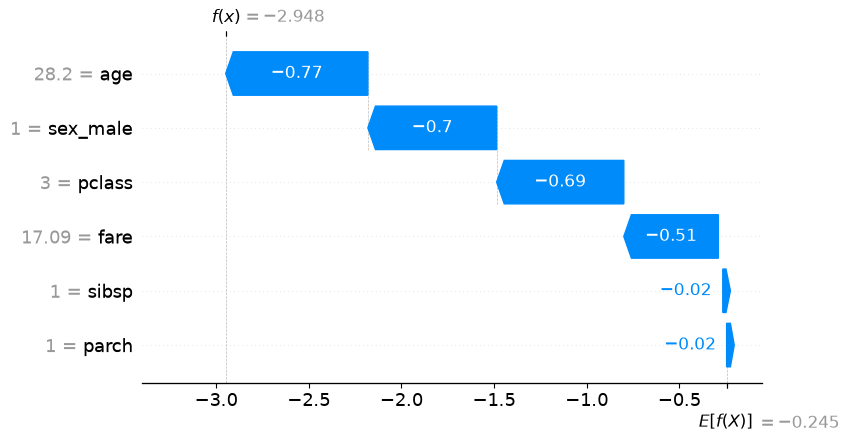

In [167]:
# Plot waterfall
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[selected_pos], max_display=len(X_test.columns))

In [168]:
passenger = X_test.iloc[selected_pos]
print(passenger)

pclass       3.00
sex_male     1.00
age         28.20
sibsp        1.00
parch        1.00
fare        17.09
Name: 341, dtype: float64


* The model predicted that this passenger would not survive, although the actual outcome was survival. The prediction was mainly driven by the passenger's third-class status, lower fare, and age, which pushed the predicted survival probability downward. Although being female pushed the prediction toward survival, the other features had a stronger combined effect, so the model remained highly confident in the incorrect prediction. This illustrates that the model learned statistical patterns from the historical Titanic data rather than understanding the circumstances of an individual passenger.

* I would investigate whether the model is systematically misclassifying certain passenger groups, particularly female passengers in third class, by examining their confusion matrix and prediction probabilities.